In [20]:
# Comprensión de los datos
import pandas as pd

df = pd.read_csv("../data/dataset_pictogramas.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         195 non-null    int64 
 1   palabra    195 non-null    object
 2   categoria  195 non-null    object
 3   archivo    195 non-null    object
 4   url        195 non-null    object
dtypes: int64(1), object(4)
memory usage: 7.7+ KB


In [21]:
# Eliminar posibles duplicados
df_clean = df.drop_duplicates()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 193 entries, 0 to 194
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         193 non-null    int64 
 1   palabra    193 non-null    object
 2   categoria  193 non-null    object
 3   archivo    193 non-null    object
 4   url        193 non-null    object
dtypes: int64(1), object(4)
memory usage: 9.0+ KB


In [22]:
# Longitud del dataset
print(f"Longitud del dataset limpio: {len(df_clean)}")

Longitud del dataset limpio: 193


categoria
acciones      30
animales      27
objetos       26
comida        24
numeros       17
lugares       16
emociones     13
colores       12
saludos       10
familia       10
transporte     8
Name: count, dtype: int64


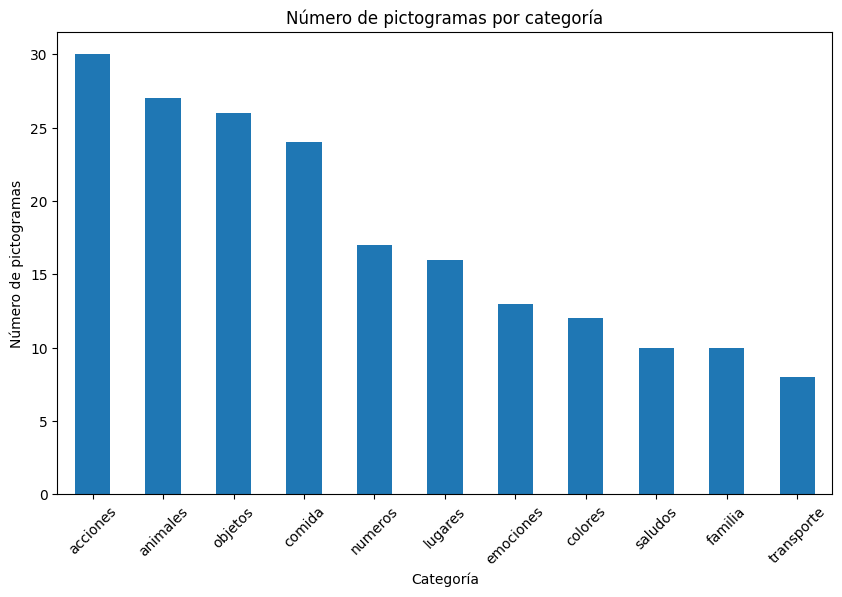

In [23]:
import matplotlib.pyplot as plt
category_counts = df_clean['categoria'].value_counts()
print(category_counts)

# Visualizar la distribución de categorías
plt.figure(figsize=(10, 6))
category_counts.plot(kind='bar')
plt.title('Número de pictogramas por categoría')
plt.xlabel('Categoría')
plt.ylabel('Número de pictogramas')
plt.xticks(rotation=45)
plt.show()

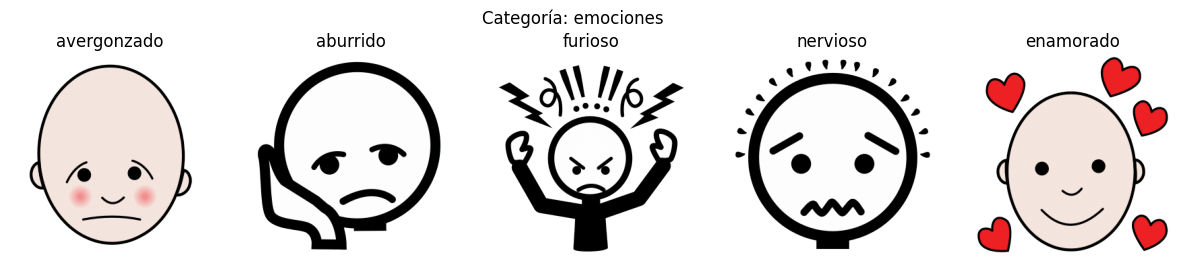

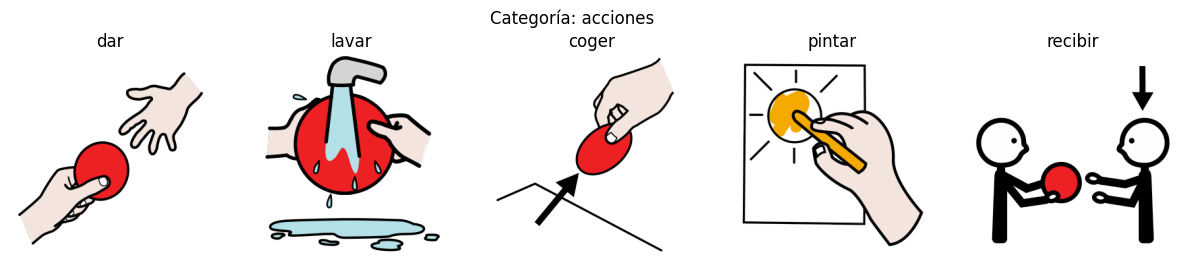

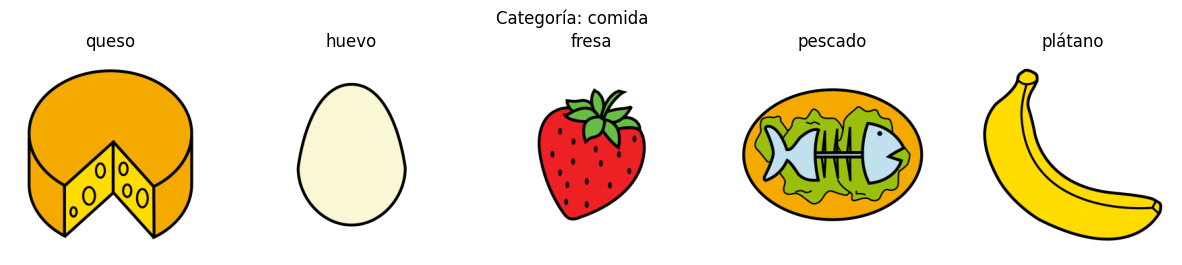

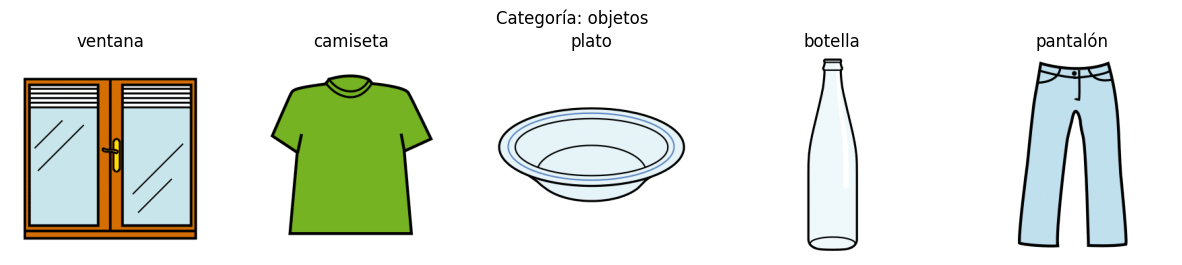

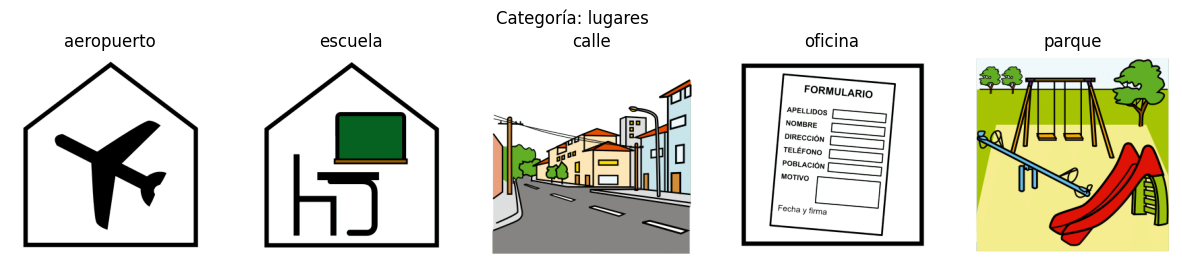

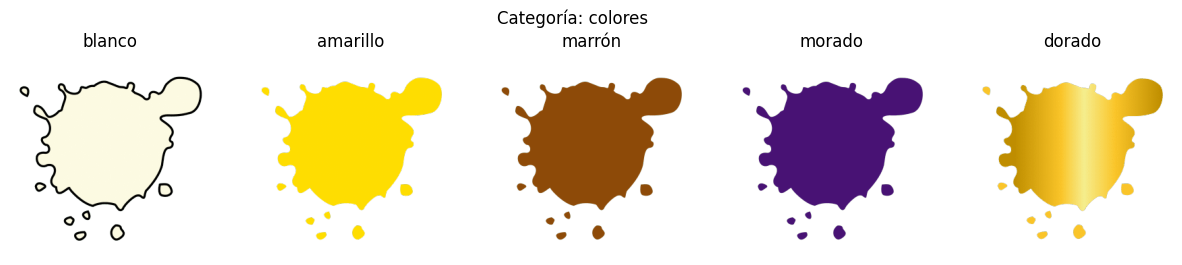

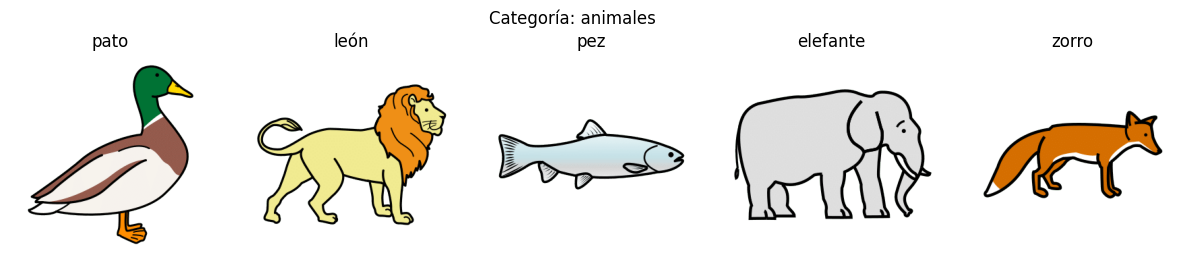

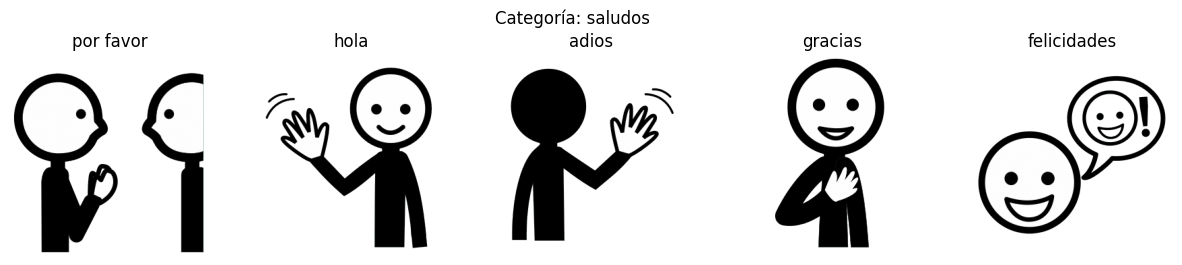

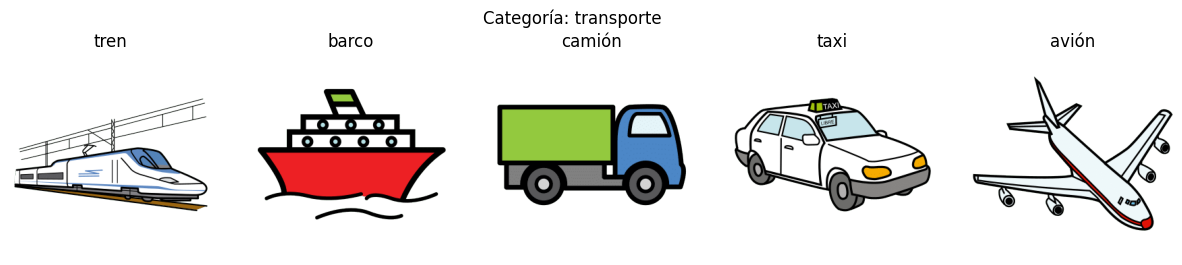

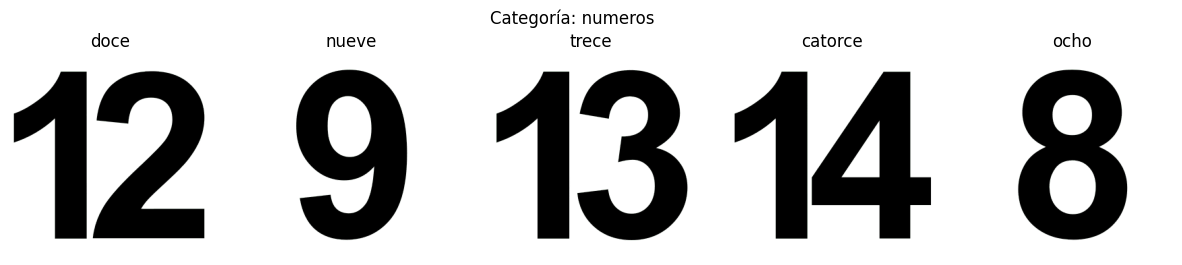

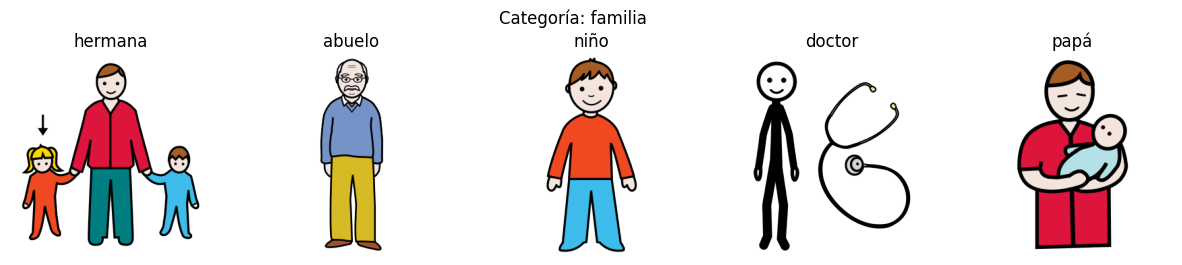

In [24]:
# Visualizar cinco pictogramas de ejemplo por categoría
import random
from PIL import Image
import os
categories = df_clean['categoria'].unique()
for category in categories:
    sample_images = df_clean[df_clean['categoria'] == category].sample(5) # Cinco por categoría
    plt.figure(figsize=(15, 3))
    for i, (_, row) in enumerate(sample_images.iterrows()):
        img_path = os.path.join("../data", row['archivo'])
        img = Image.open(img_path)
        plt.subplot(1, 5, i + 1) # Muestra las imágenes en una fila de cinco columnas
        plt.imshow(img)
        plt.axis('off')
        plt.title(row['palabra']) # Agregamos el título con la palabra   
    plt.suptitle(f'Categoría: {category}')
    plt.show()

In [ ]:
pip install wordcloud

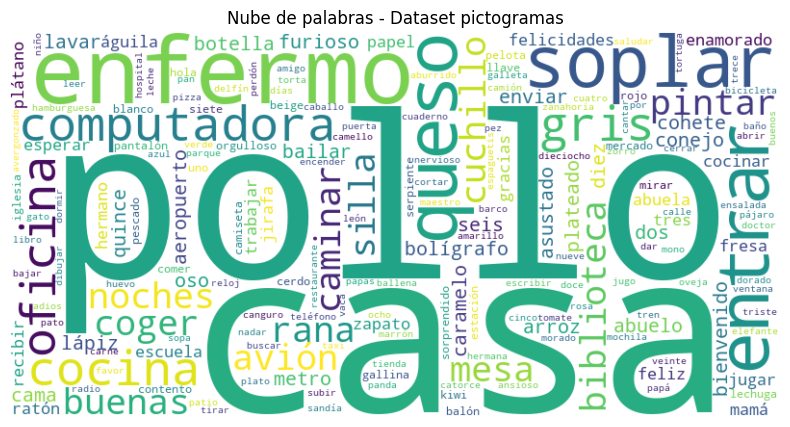

In [25]:
from wordcloud import WordCloud

text = " ".join(df_clean['palabra'])
wc = WordCloud(width=800, height=400, background_color="white").generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Nube de palabras - Dataset pictogramas")
plt.show()

In [9]:
pip install unidecode

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
# NORMALIZACIÓN DE TEXTO
# Convertir todas las palabras a minúsculas
from unidecode import unidecode
df_clean['palabra'] = df_clean['palabra'].str.lower().apply(unidecode) # Quitamos tildes por facilidad

C:\Users\rivas\AppData\Local\Temp\ipykernel_13520\3386253248.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['palabra'] = df_clean['palabra'].str.lower().apply(unidecode) # Quitamos tildes por facilidad


In [27]:
picto_dict = dict(zip(df_clean['palabra'], df_clean['archivo']))

In [30]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df_clean, test_size=0.3, random_state=42)
val, test = train_test_split(test, test_size=0.5, random_state=42)

train['split'] = 'train'
val['split'] = 'val'
test['split'] = 'test'

df_final = pd.concat([train, val, test])
df_final.to_csv("../data/dataset_pictogramas_split.csv", index=False, encoding="utf-8")

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

# Dataset palabra → categoría
X = df_clean['palabra']
y = df_clean['categoria']

# Dividir train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Vectorización con N-gramas (1-2)
vectorizer = CountVectorizer(ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Modelo Naive Bayes
nb = MultinomialNB()
nb.fit(X_train_vec, y_train)

# Predicciones
y_pred = nb.predict(X_test_vec)

# Reporte
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

    acciones       0.19      1.00      0.32        11
    animales       0.00      0.00      0.00         9
     colores       0.00      0.00      0.00         2
      comida       0.00      0.00      0.00         5
   emociones       0.00      0.00      0.00         2
     familia       0.00      0.00      0.00         6
     lugares       0.00      0.00      0.00         7
     numeros       0.00      0.00      0.00         2
     objetos       0.00      0.00      0.00         9
     saludos       0.00      0.00      0.00         2
  transporte       0.00      0.00      0.00         3

    accuracy                           0.19        58
   macro avg       0.02      0.09      0.03        58
weighted avg       0.04      0.19      0.06        58



c:\Users\rivas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rivas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rivas\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [ ]:
# RECOMENDACIONES DE COPILOT:
"""🤖 4. Modelo base del chatbot
Ya que el profesor pidió algo simple pero funcional, puedes empezar con:
🔹 Reglas simples
- Si el niño elige “queso”, el chatbot responde: “¿Te gusta el queso?” y muestra otro pictograma de comida.
🔹 Clasificación por categoría
- Usa Naive Bayes para clasificar frases en categorías de pictogramas.
- Entrena con frases infantiles y asocia cada una a una categoría."""
